### GOAL - Query big data using AI Agents without writing big data analytics code. <br>
The AI Agent will use built-in strands tools and MCP server to get the job done

## Environment Setup
Install required dependencies for the notebook including Strands SDK, AWS SDK, and MCP client libraries.

In [ ]:
# Install all required packages from requirements.txt
!pip install -r requirements.txt --quiet
!pip install --upgrade strands-agents --quiet

In [1]:
import logging

logging.basicConfig(
    level=logging.DEBUG,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    datefmt='%m/%d %H:%M:%S',
    filename='strands_debug.log'
)


### Pre-Requisites
You have run the Notebook 1

### Import Dependencies and AWS Configuration
Import required libraries and configure AWS settings for the data processing workflow.

In [2]:
# Import required libraries
import os, time, boto3, json
from strands import Agent, tool
from strands.models import BedrockModel
from strands_tools import use_aws, file_write, file_read, file_write, sleep, python_repl
from datetime import datetime
from pprint import pprint
from pydantic import BaseModel, Field
from typing import Optional, List

# Bypass tool consent for automated execution
os.environ["BYPASS_TOOL_CONSENT"] = "true"
# Specify that if python_repl tool is used, it shouldnt wait for user interaction
os.environ["PYTHON_REPL_INTERACTIVE"] = "False"

## Get Metadata Info from the json file that we created in the previous notebook


In [3]:
# Read the file metadata.json into a dictionary without using file_read
with open('metadata.json', 'r') as f:
    db_metadata = json.load(f)
db_metadata

{'database': {'name': 'awslabbigdataagentstack_tripdata_db',
  'purpose': 'Stores New York City taxi trip data for analysis and reporting'},
 'tables': [{'name': 'nyc_taxi_trip',
   'purpose': 'Contains detailed information about taxi trips in New York City, including pickup and dropoff times, locations, fare details, and payment information',
   'storage_location': 's3://670934798598-us-west-2-big-data-agent-workshop/nyc_taxi_trip/',
   'record_count': 9019594,
   'partitioning': [{'name': 'taxi_class',
     'type': 'string',
     'purpose': 'Distinguishes between different types of taxis (yellow and green)'},
    {'name': 'year',
     'type': 'string',
     'purpose': 'Year when the trip occurred'},
    {'name': 'month',
     'type': 'string',
     'purpose': 'Month when the trip occurred'}],
   'columns': [{'name': 'vendorid',
     'type': 'int',
     'purpose': 'Identifier for the vendor providing the trip data'},
    {'name': 'lpep_pickup_datetime',
     'type': 'timestamp',
     

## MCP Client Setup
We wll get tools exposed by an MCP server to discover partition columns and keys from the data in S3.<br><br>
Initialize the AWS Data Processing MCP server client to provide AI agents with AWS Glue, EMR, and Athena capabilities.

In [5]:
# Import MCP client libraries
from mcp import stdio_client, StdioServerParameters
from strands.tools.mcp import MCPClient

# Create MCP client for AWS data processing server
# This provides tools for Glue, EMR, and Athena operations
import boto3
session = boto3.Session()
credentials = session.get_credentials()

# Create MCP client for AWS data processing server
# This provides tools for Glue, EMR, and Athena operations
data_mcp_client = MCPClient(lambda: stdio_client(
    StdioServerParameters(
        command="uvx",  # Use uvx to run the MCP server
        args= [
            "awslabs.aws-dataprocessing-mcp-server@latest",
            "--allow-write",  # Enable write operations
        ],
        env= {
            "AWS_ACCESS_KEY_ID": credentials.access_key,
            "AWS_SECRET_ACCESS_KEY": credentials.secret_key,
            "AWS_SESSION_TOKEN": credentials.token,
            "FASTMCP_LOG_LEVEL": "ERROR",  # Minimize logging noise
            "AWS_REGION": session.region_name      # Set AWS region
      }
    )
))

### Let's Ask Natural Language Questions to AI Agent

In [6]:
from utils_big_data import print_tokens_costs, load_system_prompt_from_file

# Let's load the system prompt from file for running queries on data in S3 data lake
query_system_prompt = load_system_prompt_from_file("text_to_sql_prompt.txt", db_metadata=db_metadata)
query_system_prompt

'You are an expert AWS data analyst assistant specializing in querying data stored in S3 data lakes using AWS Glue and Amazon Athena and generating responses in natural language so humans can understand.\n\n## Core Responsibilities\n- Translate natural language questions into efficient, optimized Amazon Athena-compatible SQL queries\n- Execute queries using Amazon Athena\n- Respond back to the query in natural language\n\n## Technical Configuration\n- Use the database, table, and column definition from here: \n{\'database\': {\'name\': \'awslabbigdataagentstack_tripdata_db\', \'purpose\': \'Stores New York City taxi trip data for analysis and reporting\'}, \'tables\': [{\'name\': \'nyc_taxi_trip\', \'purpose\': \'Contains detailed information about taxi trips in New York City, including pickup and dropoff times, locations, fare details, and payment information\', \'storage_location\': \'s3://670934798598-us-west-2-big-data-agent-workshop/nyc_taxi_trip/\', \'record_count\': 9019594, \'p

In [9]:
model_list = ['deepseek.v3-v1:0', 'qwen.qwen3-coder-30b-a3b-v1:0', 'us.anthropic.claude-3-7-sonnet-20250219-v1:0', 'us.anthropic.claude-sonnet-4-20250514-v1:0', 'openai.gpt-oss-20b-1:0', 'openai.gpt-oss-120b-1:0']

# We will use the following model in Strands Agent
model_id = "us.anthropic.claude-sonnet-4-20250514-v1:0"

# Let's create a reusable function to process a query and return a response in a structured dictionary format
def  get_query_response(query, model_id="us.anthropic.claude-sonnet-4-20250514-v1:0"):

    # We want the response to be in structured dictionary format that returns SQL statement, its reasoning and the final response.
    class SQLQuery(BaseModel):
        sql_statement: str = Field(description="The SQL query that was generated")
        reasoning: str = Field(description="Step by step explanation of how the natural language question was translated to this SQL statement")

    class QueryResponse(BaseModel):        
        sql_queries: List[SQLQuery] = Field(description="List of SQL queries with their reasoning")
        final_response: str = Field(description="The final response generated")

    # Cerate the Bedrock Model using model_id
    model = BedrockModel(model_id=model_id)

    #Let's us ethe MCP client we created earlier
    with data_mcp_client:
        # Get the data processing tools from MCP server
        data_tools = data_mcp_client.list_tools_sync()

        # Optimize tools by passing just what we need instead of all 32 tools
        curated_data_tools = ['manage_aws_athena_query_executions']

        # Extract just the tools that we need.
        filtered_tools = [tool for tool in data_tools if tool.tool_name in curated_data_tools]

        #Add the following tools so we can generate charts or read / write to files if needed.
        final_tools = [python_repl, file_read, file_write] + filtered_tools
    
        # Pass the system prompt, the LLM we use with bedrock, and all the tools to the agent
        data_lake_agent = Agent(system_prompt = query_system_prompt, model=model, tools=final_tools)

        # Invoke the Agent
        temp_response = data_lake_agent(query)

        #Convert the agents response into a structured output
        response = data_lake_agent.structured_output(QueryResponse, "Extract the structured output of sql queries, reasoning, and the final response")

        #Convert the object into a dictionary
        response_dict = response.model_dump()
        return response_dict

In [ ]:
response = get_query_response(f"How many rides went to Airport each month in 2025?")
pprint(response)

I'll help you find how many rides went to airports each month in 2025. Let me analyze the data and create a query to get this information.
Tool #1: manage_aws_athena_query_executions
Let me try again with a result configuration:
Tool #2: manage_aws_athena_query_executions
Now let me check the query status and get the results:
Tool #3: manage_aws_athena_query_executions
Great! The query succeeded. Now let me get the results:
Tool #4: manage_aws_athena_query_executions
Perfect! I have the results. Let me also run a query to get more details about airport rides including both JFK and Newark separately, and also check if there are any rides with airport fees to get a more comprehensive view:
Tool #5: manage_aws_athena_query_executions

Tool #6: python_repl


╭───────────────────────────────────────────── Executing Python Code ─────────────────────────────────────────────╮
│ import time                                                                                                     │
│ time.sleep(3)  # Wait for query to complete                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Running in standard mode...

✓ Code executed successfully (3.01s)


Tool #7: manage_aws_athena_query_executions
Now let me format the final response:
Tool #8: python_repl


...

Running in standard mode...

Output:

SQL Statement List:

Query 1:
SELECT 
    month,
    COUNT(*) as airport_rides
FROM awslabbigdataagentstack_tripdata_db.nyc_taxi_trip
WHERE year = '2025'
    AND (ratecodeid = 2 OR ratecodeid = 3)  -- JFK (2) and Newark (3) airports
GROUP BY month
ORDER BY month

Query 2:
SELECT 
    month,
    CASE 
        WHEN ratecodeid = 2 THEN 'JFK Airport'
        WHEN ratecodeid = 3 THEN 'Newark Airport'
        ELSE 'Other Airport'
    END as airport_type,
    COUNT(*) as rides_count
FROM awslabbigdataagentstack_tripdata_db.nyc_taxi_trip
WHERE year = '2025'
    AND (ratecodeid = 2 OR ratecodeid = 3 OR airport_fee > 0)
GROUP BY month, 
    CASE 
        WHEN ratecodeid = 2 THEN 'JFK Airport'
        WHEN ratecodeid = 3 THEN 'Newark Airport'
        ELSE 'Other Airport'
    END
ORDER BY month, airport_type

================================================================================

SQL Reasoning List:

Query 1 Reasoning:
First Query Reasoning:
1. I filtered the data for year = '2025' to focus on 2025 data only
2. I used ratecodeid = 2 (JFK Airport) and ratecodeid = 3 (Newark Airport) to identify airport rides based on the 
rate code definitions
3. I grouped by month to get monthly counts
4. I used COUNT(*) to count the total number of airport rides per month
5. I ordered by month to present results chronologically

Query 2 Reasoning:
Second Query Reasoning:
1. I expanded the analysis to include rides with airport_fee > 0 to capture any other airport-related trips
2. I used a CASE statement to categorize the airport types (JFK, Newark, Other Airport)
3. I grouped by both month and airport type to get a breakdown by specific airports
4. This provides more detailed insights into which airports are most popular each month

================================================================================

Final Response:
Based on my analysis of the NYC taxi trip data for 2025, here are the airport ride counts by month:

**Total Airport Rides (JFK + Newark only):**
- May 2025: 144,247 rides
- June 2025: 132,333 rides

**Detailed Breakdown by Airport:**

**May 2025:**
- JFK Airport: 130,845 rides
- Newark Airport: 13,402 rides  
- Other Airport rides (with airport fees): 213,444 rides
- **Total airport-related rides: 357,691**

**June 2025:**
- JFK Airport: 119,899 rides
- Newark Airport: 12,434 rides
- Other Airport rides (with airport fees): 203,147 rides
- **Total airport-related rides: 335,480**

**Key Insights:**
1. JFK Airport is significantly more popular than Newark, accounting for about 90% of the major airport rides
2. There's a decline from May to June in both JFK (-8.4%) and Newark (-7.2%) rides
3. When including all airport-fee rides, the total airport-related trips are much higher, suggesting there are 
other airports or airport-related services captured in the data
4. The "Other Airport" category (rides with airport fees but not JFK/Newark rate codes) represents the largest 
portion, indicating additional airport services or locations beyond the major airports

✓ Code executed successfully (0.02s)
User objects in namespace: 3 items
 - i = 2
 - sql = "SELECT \n    month,\n    CASE \n        WHEN ratecodeid = 2 THEN 'JFK Airport'\n        WHEN ratecodeid =
3 THEN 'Newark Airport'\n        ELSE 'Other Airport'\n    END as airport_type,\n    COUNT(*) as rides_count\nFROM 
awslabbigdataagentstack_tripdata_db.nyc_taxi_trip\nWHERE year = '2025'\n    AND (ratecodeid = 2 OR ratecodeid = 3 
OR airport_fee > 0)\nGROUP BY month, \n    CASE \n        WHEN ratecodeid = 2 THEN 'JFK Airport'\n        WHEN 
ratecodeid = 3 THEN 'Newark Airport'\n        ELSE 'Other Airport'\n    END\nORDER BY month, airport_type"
 - reasoning = 'Second Query Reasoning:\n1. I expanded the analysis to include rides with airport_fee > 0 to 
capture any other airport-related trips\n2. I used a CASE statement to categorize the airport types (JFK, Newark, 
Other Airport)\n3. I grouped by both month and airport type to get a breakdown by specific airports\n4. This 
provides more detailed insights into which airports are most popular each month'

## Final Response

**sql_statement_list:**
1. ```sql
SELECT 
    month,
    COUNT(*) as airport_rides
FROM awslabbigdataagentstack_tripdata_db.nyc_taxi_trip
WHERE year = '2025'
    AND (ratecodeid = 2 OR ratecodeid = 3)  -- JFK (2) and Newark (3) airports
GROUP BY month
ORDER BY month
```

2. ```sql
SELECT 
    month,
    CASE 
        WHEN ratecodeid = 2 THEN 'JFK Airport'
        WHEN ratecodeid = 3 THEN 'Newark Airport'
        ELSE 'Other Airport'
    END as airport_type,
    COUNT(*) as rides_count
FROM awslabbigdataagentstack_tripdata_db.nyc_taxi_trip
WHERE year = '2025'
    AND (ratecodeid = 2 OR ratecodeid = 3 OR airport_fee > 0)
GROUP BY month, 
    CASE 
        WHEN ratecodeid = 2 THEN 'JFK Airport'
        WHEN ratecodeid = 3 THEN 'Newark Airport'
        ELSE 'Other Airport'
    END
ORDER BY month, airport_type
```

**sql_reasoning_list:**
1. **First Query Reasoning:** I filtered the data for year = '2025' to focus on 2025 data only. I used ratecodeid = 2 (JFK Airport) and

In [ ]:
pprint(response)

I'll help you find the number of taxi vendors and create a bar chart showing ride count and fare amount by vendor. Let me start by querying the data.
Tool #1: manage_aws_athena_query_executions
Let me try with a workgroup specified:
Tool #2: manage_aws_athena_query_executions
Let me provide a result configuration with an S3 output location:
Tool #3: manage_aws_athena_query_executions
Now let me check the query status and get the results:
Tool #4: manage_aws_athena_query_executions
Great! The query completed successfully. Now let me get the results:
Tool #5: manage_aws_athena_query_executions
Perfect! Now I have the data. Let me create a bar chart to visualize the ride count and fare amount by vendor:
Tool #6: python_repl


╭───────────────────────────────────────────── Executing Python Code ─────────────────────────────────────────────╮
│ import matplotlib.pyplot as plt                                                                                 │
│ import numpy as np                                                                                              │
│                                                                                                                 │
│ # Data from the query results                                                                                   │
│ vendors = [1, 2, 6, 7]                                                                                          │
│ ride_counts = [1731917, 7152165, 4678, 130834]                                                                  │
│ total_fare_amounts = [34298915.82, 131844128.29, 13437.15, 2149679.44]                                          │
│                                                                                                                 │
│ # Convert fare amounts to millions for better readability                                                       │
│ fare_amounts_millions = [amount / 1000000 for amount in total_fare_amounts]                                     │
│                                                                                                                 │
│ # Create figure with two subplots                                                                               │
│ fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))                                                           │
│                                                                                                                 │
│ # Bar chart for ride counts                                                                                     │
│ bars1 = ax1.bar(vendors, ride_counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])                       │
│ ax1.set_xlabel('Vendor ID')                                                                                     │
│ ax1.set_ylabel('Number of Rides')                                                                               │
│ ax1.set_title('Ride Count by Taxi Vendor')                                                                      │
│ ax1.grid(axis='y', alpha=0.3)                                                                                   │
│                                                                                                                 │
│ # Add value labels on bars                                                                                      │
│ for bar, count in zip(bars1, ride_counts):                                                                      │
│     height = bar.get_height()                                                                                   │
│     ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,                                            │
│              f'{count:,}', ha='center', va='bottom', fontsize=10)                                               │
│                                                                                                                 │
│ # Bar chart for fare amounts (in millions)                                                                      │
│ bars2 = ax2.bar(vendors, fare_amounts_millions, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])             │
│ ax2.set_xlabel([

Running in standard mode...

╭───────────────────────────────────────────────── Python Error ──────────────────────────────────────────────────╮
│ Traceback (most recent call last):                                                                              │
│   File "/Users/giryoong/anaconda3/envs/thalaiva/lib/python3.12/site-packages/strands_tools/python_repl.py", lin │
│     repl_state.execute(code)                                                                                    │
│   File "/Users/giryoong/anaconda3/envs/thalaiva/lib/python3.12/site-packages/strands_tools/python_repl.py", lin │
│     exec(code, self._namespace)                                                                                 │
│   File "<string>", line 1, in <module>                                                                          │
│ ModuleNotFoundError: No module named 'matplotlib'                                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Let me install matplotlib and create the chart:
Tool #7: python_repl


...

matplotlib installed successfully!

✓ Code executed successfully (21.84s)
User objects in namespace: 3 items
 - i = 2
 - sql = "SELECT \n    month,\n    CASE \n        WHEN ratecodeid = 2 THEN 'JFK Airport'\n        WHEN ratecodeid =
3 THEN 'Newark Airport'\n        ELSE 'Other Airport'\n    END as airport_type,\n    COUNT(*) as rides_count\nFROM 
awslabbigdataagentstack_tripdata_db.nyc_taxi_trip\nWHERE year = '2025'\n    AND (ratecodeid = 2 OR ratecodeid = 3 
OR airport_fee > 0)\nGROUP BY month, \n    CASE \n        WHEN ratecodeid = 2 THEN 'JFK Airport'\n        WHEN 
ratecodeid = 3 THEN 'Newark Airport'\n        ELSE 'Other Airport'\n    END\nORDER BY month, airport_type"
 - reasoning = 'Second Query Reasoning:\n1. I expanded the analysis to include rides with airport_fee > 0 to 
capture any other airport-related trips\n2. I used a CASE statement to categorize the airport types (JFK, Newark, 
Other Airport)\n3. I grouped by both month and airport type to get a breakdown by specific airports\n4. This 
provides more detailed insights into which airports are most popular each month'

Now let me create the visualization:
Tool #8: python_repl


╭───────────────────────────────────────────── Executing Python Code ─────────────────────────────────────────────╮
│ import matplotlib.pyplot as plt                                                                                 │
│ import numpy as np                                                                                              │
│                                                                                                                 │
│ # Data from the query results                                                                                   │
│ vendors = [1, 2, 6, 7]                                                                                          │
│ ride_counts = [1731917, 7152165, 4678, 130834]                                                                  │
│ total_fare_amounts = [34298915.82, 131844128.29, 13437.15, 2149679.44]                                          │
│                                                                                                                 │
│ # Convert fare amounts to millions for better readability                                                       │
│ fare_amounts_millions = [amount / 1000000 for amount in total_fare_amounts]                                     │
│                                                                                                                 │
│ # Create figure with two subplots                                                                               │
│ fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))                                                           │
│                                                                                                                 │
│ # Bar chart for ride counts                                                                                     │
│ bars1 = ax1.bar(vendors, ride_counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])                       │
│ ax1.set_xlabel('Vendor ID')                                                                                     │
│ ax1.set_ylabel('Number of Rides')                                                                               │
│ ax1.set_title('Ride Count by Taxi Vendor')                                                                      │
│ ax1.grid(axis='y', alpha=0.3)                                                                                   │
│                                                                                                                 │
│ # Add value labels on bars                                                                                      │
│ for bar, count in zip(bars1, ride_counts):                                                                      │
│     height = bar.get_height()                                                                                   │
│     ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,                                            │
│              f'{count:,}', ha='center', va='bottom', fontsize=10)                                               │
│                                                                                                                 │
│ # Bar chart for fare amounts (in millions)                                                                      │
│ bars2 = ax2.bar(vendors, fare_amounts_millions, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])             │
│ ax2.set_xlabel([

Running in standard mode...

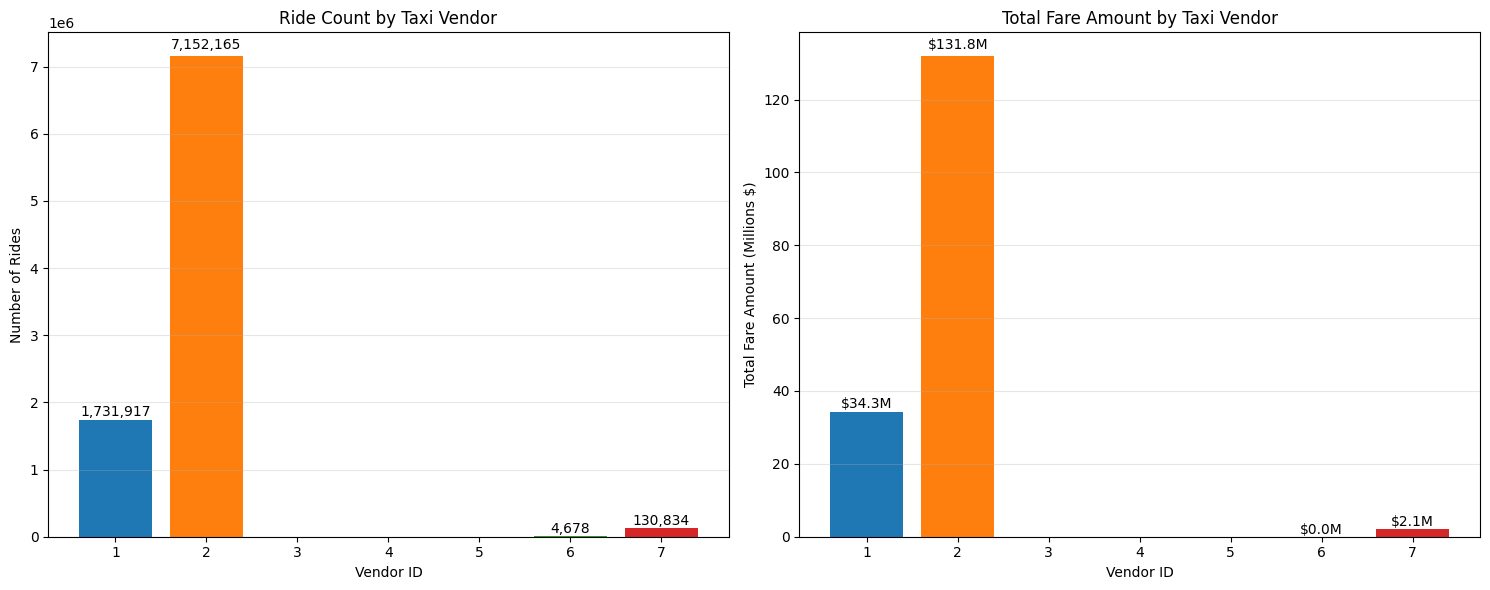

Output:

Summary of Taxi Vendors:
==================================================
Vendor 1:
  - Rides: 1,731,917
  - Total Fare: $34,298,915.82
  - Average Fare per Ride: $19.80

Vendor 2:
  - Rides: 7,152,165
  - Total Fare: $131,844,128.29
  - Average Fare per Ride: $18.43

Vendor 6:
  - Rides: 4,678
  - Total Fare: $13,437.15
  - Average Fare per Ride: $2.87

Vendor 7:
  - Rides: 130,834
  - Total Fare: $2,149,679.44
  - Average Fare per Ride: $16.43

Total number of taxi vendors: 4
Total rides across all vendors: 9,019,594
Total fare amount across all vendors: $168,306,160.70

✓ Code executed successfully (146.03s)
User objects in namespace: 7 items
 - i = 3
 - sql = "SELECT \n    month,\n    CASE \n        WHEN ratecodeid = 2 THEN 'JFK Airport'\n        WHEN ratecodeid =
3 THEN 'Newark Airport'\n        ELSE 'Other Airport'\n    END as airport_type,\n    COUNT(*) as rides_count\nFROM 
awslabbigdataagentstack_tripdata_db.nyc_taxi_trip\nWHERE year = '2025'\n    AND (ratecodeid = 2 OR ratecodeid = 3 
OR airport_fee > 0)\nGROUP BY month, \n    CASE \n        WHEN ratecodeid = 2 THEN 'JFK Airport'\n        WHEN 
ratecodeid = 3 THEN 'Newark Airport'\n        ELSE 'Other Airport'\n    END\nORDER BY month, airport_type"
 - reasoning = 'Second Query Reasoning:\n1. I expanded the analysis to include rides with airport_fee > 0 to 
capture any other airport-related trips\n2. I used a CASE statement to categorize the airport types (JFK, Newark, 
Other Airport)\n3. I grouped by both month and airport type to get a breakdown by specific airports\n4. This 
provides more detailed insights into which airports are most popular each month'
 - count = 130834
 - height = np.float64(2.14967944)
 - amount = 2.14967944
 - vendor = 7

## Final Response:

**sql_statement_list:**
```sql
SELECT 
    vendorid,
    COUNT(*) as ride_count,
    SUM(fare_amount) as total_fare_amount
FROM awslabbigdataagentstack_tripdata_db.nyc_taxi_trip 
WHERE vendorid IS NOT NULL
GROUP BY vendorid
ORDER BY vendorid
```

**sql_reasoning_list:**
1. **SELECT clause**: I selected `vendorid` to identify each unique vendor, `COUNT(*)` to get the total number of rides per vendor, and `SUM(fare_amount)` to calculate the total fare amount collected by each vendor.

2. **FROM clause**: I queried the main table `awslabbigdataagentstack_tripdata_db.nyc_taxi_trip` which contains all the taxi trip data.

3. **WHERE clause**: I filtered out records where `vendorid IS NOT NULL` to ensure we only count valid vendor records and avoid including any null vendor IDs in our analysis.

4. **GROUP BY clause**: I grouped the results by `vendorid` to aggregate the ride counts and fare amounts for each unique vendor.

5. **ORDER BY clause**: I ordered the results by

In [11]:
response = get_query_response(f"How many taxi vendors are there? Plot a bar chart with ride count and fare amount.")
print(response)

In [ ]:
response = get_query_response("For the top 25 percentile of ride fares per yellow / green class, what is ratio of tips to total fare? If I am a taxi driver which routes and times should I drive to get the most tips?")
pprint(response)

I'll help you analyze the tip patterns for high-fare rides and identify the best routes and times for maximizing tips. Let me break this down into steps:

1. First, I'll find the top 25 percentile threshold for ride fares by taxi class
2. Then analyze the tip-to-fare ratio for these high-fare rides
3. Finally, identify the best routes (pickup/dropoff locations) and times for maximizing tips

Let me start by executing these queries:
Tool #1: manage_aws_athena_query_executions
Let me configure the result location and try again:
Tool #2: manage_aws_athena_query_executions

Tool #3: python_repl


╭───────────────────────────────────────────── Executing Python Code ─────────────────────────────────────────────╮
│ import time                                                                                                     │
│ time.sleep(5)                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Running in standard mode...

✓ Code executed successfully (8.51s)
User objects in namespace: 7 items
 - i = 3
 - sql = "SELECT \n    month,\n    CASE \n        WHEN ratecodeid = 2 THEN 'JFK Airport'\n        WHEN ratecodeid =
3 THEN 'Newark Airport'\n        ELSE 'Other Airport'\n    END as airport_type,\n    COUNT(*) as rides_count\nFROM 
awslabbigdataagentstack_tripdata_db.nyc_taxi_trip\nWHERE year = '2025'\n    AND (ratecodeid = 2 OR ratecodeid = 3 
OR airport_fee > 0)\nGROUP BY month, \n    CASE \n        WHEN ratecodeid = 2 THEN 'JFK Airport'\n        WHEN 
ratecodeid = 3 THEN 'Newark Airport'\n        ELSE 'Other Airport'\n    END\nORDER BY month, airport_type"
 - reasoning = 'Second Query Reasoning:\n1. I expanded the analysis to include rides with airport_fee > 0 to 
capture any other airport-related trips\n2. I used a CASE statement to categorize the airport types (JFK, Newark, 
Other Airport)\n3. I grouped by both month and airport type to get a breakdown by specific airports\n4. This 
provides more detailed insights into which airports are most popular each month'
 - count = 130834
 - height = np.float64(2.14967944)
 - amount = 2.14967944
 - vendor = 7

In [ ]:
pprint(response)